In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from utils.dataset_loader import mimic_loader

root = "ADS599-Capstone/raw_data"

df_vitals = mimic_loader(path=root, name='vitals')
df = mimic_loader(path=root, name='cohort_with_triage')

Generating vitals split:   0%|          | 0/1496038 [00:00<?, ? examples/s]

In [8]:
patient_state = pd.read_parquet("../data/empty_patient_state_reduced.parquet")

In [2]:
print(f"Shape: {df_vitals.shape}")
print(f"Unique ED stays: {df_vitals['ed_stay_id'].nunique():,}")
print(f"Unique patients: {df_vitals['subject_id'].nunique():,}")
df_vitals.head()

Shape: (1496038, 11)
Unique ED stays: 387,283
Unique patients: 191,231


,ed_stay_id,subject_id,charttime,temperature,heartrate,resprate,o2sat,sbp,dbp,rhythm,pain
0,30000012,11714491,2126-02-14 20:22:00,98.8,96.0,18.0,93.0,160.0,54.0,NaN,0
1,30000012,11714491,2126-02-14 23:43:00,NaN,80.0,13.0,99.0,112.0,44.0,NaN,0
2,30000012,11714491,2126-02-15 00:50:00,98.6,88.0,16.0,100.0,135.0,51.0,NaN,0
3,30000038,13821532,2152-12-07 16:38:00,97.1,54.0,18.0,95.0,143.0,73.0,NaN,0
4,30000038,13821532,2152-12-07 19:17:00,NaN,78.0,20.0,96.0,141.0,61.0,NaN,0


# Missing Values

               count  pct_missing
rhythm       1437948         96.1
temperature   546057         36.5
pain          421912         28.2
o2sat         130027          8.7
resprate       85701          5.7
sbp            77652          5.2
dbp            77652          5.2
heartrate      66580          4.5
charttime          0          0.0
ed_stay_id         0          0.0
subject_id         0          0.0


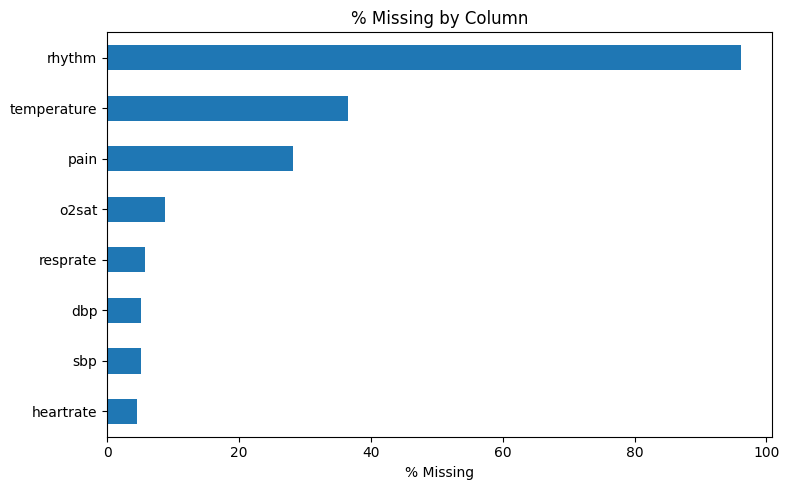

In [3]:
missing = df_vitals.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_vitals) * 100).round(1)

missing_df = pd.DataFrame({'count': missing, 'pct_missing': missing_pct})
print(missing_df)

missing_pct[missing_pct > 0].sort_values().plot(
    kind='barh', figsize=(8, 5), title='% Missing by Column'
)
plt.xlabel('% Missing')
plt.tight_layout()
plt.show()

# Rhythm — Unique Values

Unique rhythm values (including NaN): 1148

rhythm
NaN                    1437948
Sinus Rhythm             18414
Normal Sinus Rhythm      11944
Atrial Fibrillation       5168
Sinus Tachycardia         4981
                        ...   
157/99                       1
tachy                        1
130/88                       1
AFtutter                     1
Aflutter                     1
Name: count, Length: 1148, dtype: int64


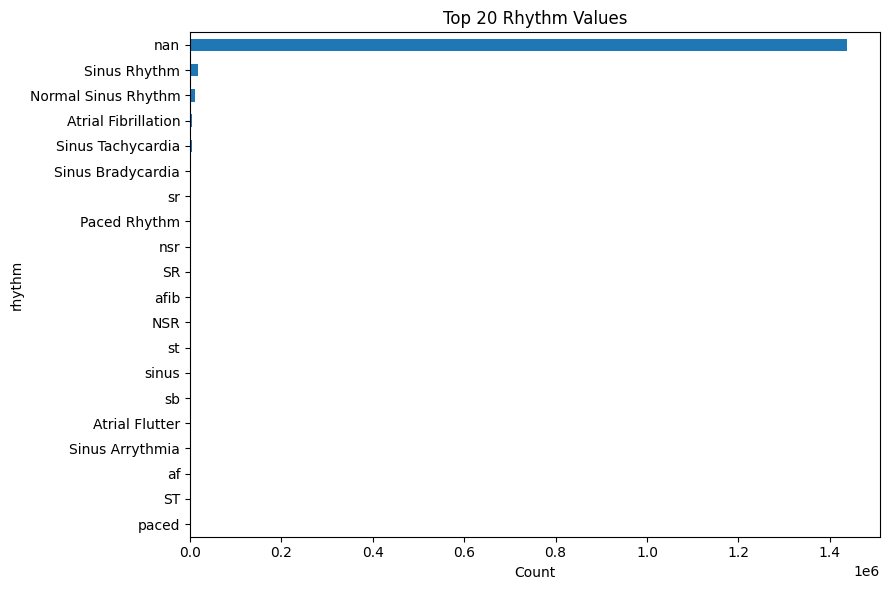

In [4]:
rhythm_counts = df_vitals['rhythm'].value_counts(dropna=False)
print(f"Unique rhythm values (including NaN): {df_vitals['rhythm'].nunique(dropna=False)}")
print()
print(rhythm_counts)

rhythm_counts.head(20).sort_values().plot(
    kind='barh', figsize=(9, 6), title='Top 20 Rhythm Values'
)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Readings per ED Stay

Average readings per stay: 3.86

count    387283.0
mean          3.9
std           3.3
min           1.0
25%           2.0
50%           3.0
75%           5.0
90%           8.0
95%          10.0
99%          16.0
max         109.0
dtype: float64


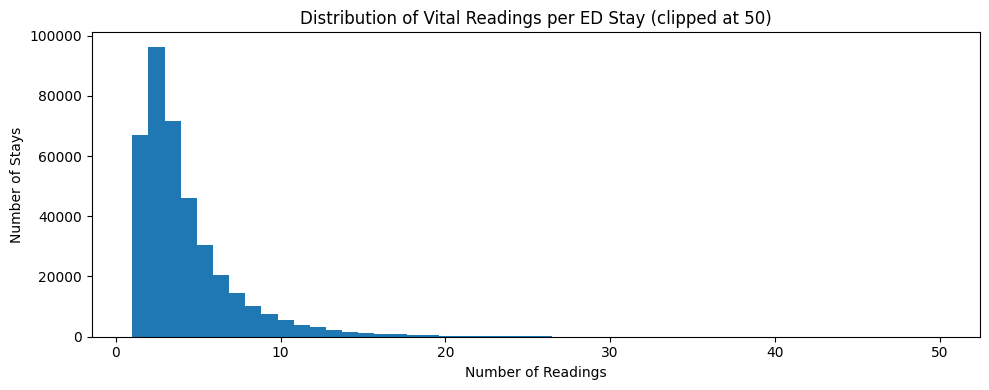

In [5]:
readings_per_stay = df_vitals.groupby('ed_stay_id').size()

print(f"Average readings per stay: {readings_per_stay.mean():.2f}")
print()
print(readings_per_stay.describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1))

readings_per_stay.clip(upper=50).plot(
    kind='hist', bins=50, figsize=(10, 4),
    title='Distribution of Vital Readings per ED Stay (clipped at 50)'
)
plt.xlabel('Number of Readings')
plt.ylabel('Number of Stays')
plt.tight_layout()
plt.show()

# Numerical Column Distributions

In [14]:
numeric_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

print(df_vitals[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))

       temperature   heartrate    resprate       o2sat         sbp         dbp
count    949981.00  1429458.00  1410337.00  1366011.00  1418386.00  1418386.00
mean         98.00       81.22       17.80       97.91      128.46       74.26
std           8.13       18.02       80.19       15.07       22.99      178.14
min           0.00        0.00        0.00        0.00        0.00        0.00
1%           96.20       49.00       12.00       91.00       83.00       40.00
5%           97.10       56.00       14.00       94.00       96.00       49.00
25%          97.80       69.00       16.00       97.00      113.00       63.00
50%          98.10       79.00       18.00       98.00      126.00       72.00
75%          98.50       91.00       18.00      100.00      142.00       82.00
95%          99.60      113.00       24.00      100.00      169.00       98.00
99%         101.80      134.00       30.00      100.00      192.00      111.00
max         989.00     1109.00    94452.00     9997.

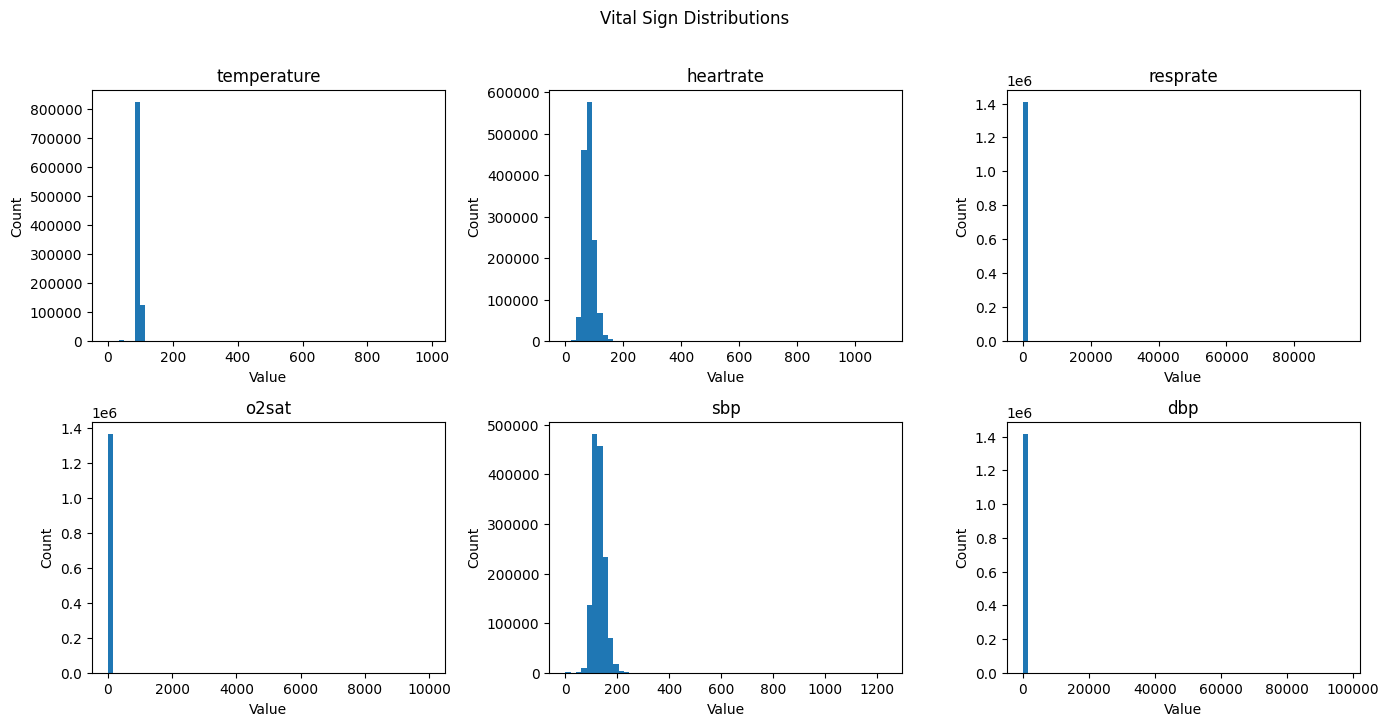

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_vitals[col].dropna()
    axes[i].hist(data, bins=60, edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# hide unused subplot
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Vital Sign Distributions', y=1.01)
plt.tight_layout()
plt.show()

# Outlier Detection

In [10]:
# Clinically plausible ranges for flagging extreme outliers
VALID_RANGES = {
    'temperature': (70, 115),
    'heartrate':   (20, 300),
    'resprate':    (6, 80),
    'o2sat':       (80, 100),
    'sbp':         (20, 300),
    'dbp':         (20, 170),
}

print("Outlier counts (outside clinically plausible range):")
print(f"{'Column':<15} {'Low':>8} {'High':>8} {'Total':>8} {'% of non-null':>15}")
print('-' * 60)
for col, (lo, hi) in VALID_RANGES.items():
    s = df_vitals[col].dropna()
    n_low  = (s < lo).sum()
    n_high = (s > hi).sum()
    n_total = n_low + n_high
    pct = n_total / len(s) * 100
    print(f"{col:<15} {n_low:>8,} {n_high:>8,} {n_total:>8,} {pct:>14.2f}%")

Outlier counts (outside clinically plausible range):
Column               Low     High    Total   % of non-null
------------------------------------------------------------
temperature        4,165       83    4,248           0.45%
heartrate            588       10      598           0.04%
resprate             261       34      295           0.02%
o2sat              1,742       38    1,780           0.13%
sbp                2,154        4    2,158           0.15%
dbp                  410    1,259    1,669           0.12%


In [ ]:
# Box plots to visualise spread and outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_vitals[col].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True, flierprops={'markersize': 2, 'alpha': 0.3})
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Vital Sign Box Plots', y=1.01)
plt.tight_layout()
plt.show()

# Correlations

             temperature  heartrate  resprate  o2sat    sbp    dbp
temperature        1.000      0.015    -0.000 -0.001  0.015  0.001
heartrate          0.015      1.000     0.012 -0.013 -0.014  0.014
resprate          -0.000      0.012     1.000 -0.001  0.004 -0.000
o2sat             -0.001     -0.013    -0.001  1.000  0.002  0.001
sbp                0.015     -0.014     0.004  0.002  1.000  0.023
dbp                0.001      0.014    -0.000  0.001  0.023  1.000


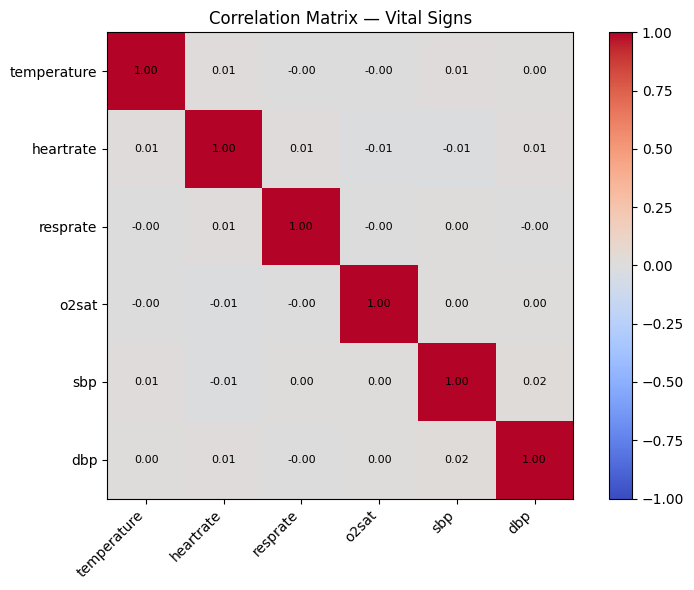

In [4]:
corr = df_vitals[numeric_cols].corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)

for row in range(len(numeric_cols)):
    for col in range(len(numeric_cols)):
        ax.text(col, row, f"{corr.iloc[row, col]:.2f}",
                ha='center', va='center', fontsize=8)

ax.set_title('Correlation Matrix — Vital Signs')
plt.tight_layout()
plt.show()

# Clean Up

In [13]:
from utils.clean_cohort_df import fix_triage_outliers, clean_pain_column

df_vitals['charttime'] = pd.to_datetime(df_vitals['charttime'])

Import cleaning utilities and cast `charttime` to datetime early so all subsequent sort and merge operations work correctly.

In [15]:
df_vitals.drop(columns='rhythm', inplace=True)

vital_fill_df = df[['ed_stay_id', 'subject_id', 'ed_intime', 'pain']].copy()
vital_fill_df[numeric_cols] = df[numeric_cols]
vital_fill_df.rename(columns={'ed_intime': 'charttime'}, inplace=True)

df_vitals = pd.concat([df_vitals, vital_fill_df]).sort_values(['ed_stay_id', 'charttime']).reset_index(drop=True)

Drop `rhythm` (too sparse to impute meaningfully) and bring in the triage row from the cohort dataframe as a synthetic first reading for each stay. This anchors the time series at `ed_intime` and gives the ffill/bfill pass something to propagate for patients who have triage vitals but no charted vitals readings.

In [16]:
df_vitals = fix_triage_outliers(df_vitals)
df_vitals = clean_pain_column(df_vitals)

Clip physiologically implausible outliers using the same ranges established for triage, and standardise the pain column. Pain values that don't map to the 0–10 scale (e.g. free-text entries) are preserved as `'Other'`.

In [17]:
df_vitals[numeric_cols] = df_vitals.groupby('ed_stay_id')[numeric_cols].ffill()
df_vitals[numeric_cols] = df_vitals.groupby('ed_stay_id')[numeric_cols].bfill()

Forward fill then backward fill within each ED stay. The ffill propagates the last known reading forward in time; the bfill catches any leading NaNs at the start of a stay (where ffill has nothing to work from). Both passes are bounded to the stay — values never bleed across stays.

In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

it_imp = IterativeImputer(random_state=10, verbose=2)
imputed_array = it_imp.fit_transform(df_vitals[numeric_cols])
df_vitals[numeric_cols] = imputed_array

[IterativeImputer] Completing matrix with shape (1893713, 6)
[IterativeImputer] Ending imputation round 1/10, elapsed time 2.16
[IterativeImputer] Change: 65.49281935287989, scaled tolerance: 0.295 
[IterativeImputer] Ending imputation round 2/10, elapsed time 4.29
[IterativeImputer] Change: 19.29152912135558, scaled tolerance: 0.295 
[IterativeImputer] Ending imputation round 3/10, elapsed time 6.38
[IterativeImputer] Change: 5.961602359987879, scaled tolerance: 0.295 
[IterativeImputer] Ending imputation round 4/10, elapsed time 8.48
[IterativeImputer] Change: 1.8374366476006116, scaled tolerance: 0.295 
[IterativeImputer] Ending imputation round 5/10, elapsed time 10.62
[IterativeImputer] Change: 0.5663163122712689, scaled tolerance: 0.295 
[IterativeImputer] Ending imputation round 6/10, elapsed time 12.71
[IterativeImputer] Change: 0.17454441095152617, scaled tolerance: 0.295 
[IterativeImputer] Early stopping criterion reached.


Any stays that had no readings at all for a given column (so ff/bfill couldn't help) are filled using `IterativeImputer`, which models each feature as a function of the others. The imputed numpy array is assigned directly back to avoid index misalignment.

# Feature Engineering

In [24]:
# Few duplicates so reset prior
df_vitals = df_vitals.sort_values('charttime').groupby(['ed_stay_id', 'charttime'], as_index=False).last()

In [ ]:
vital_cols = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp']

df_vitals = df_vitals.sort_values(['ed_stay_id', 'charttime']).reset_index(drop=True)

df_vitals['charttime'] = pd.to_datetime(df_vitals['charttime'])

# shared time delta (hours since previous reading, within stay)
df_vitals['time_since_last_hrs'] = (
    df_vitals.groupby('ed_stay_id')['charttime']
    .diff()
    .dt.total_seconds() / 3600
)

for col in vital_cols:
    # 2-hour rolling average (time-based window, within stay)
    df_vitals[f'{col}_rolling2h'] = (
        df_vitals.groupby('ed_stay_id', group_keys=False)
        .apply(lambda g: g.set_index('charttime')[col].rolling('2h').mean())
        .values
    )

    # 1-step delta
    df_vitals[f'{col}_delta'] = df_vitals.groupby('ed_stay_id')[col].diff()

    # rate of change (units per hour)
    df_vitals[f'{col}_rate'] = df_vitals[f'{col}_delta'] / df_vitals['time_since_last_hrs']

print("New columns added:")
new_cols = ['time_since_last_hrs'] + [f'{c}{s}' for c in vital_cols for s in ('_rolling2h', '_delta', '_rate')]
print(new_cols)

For each vital sign: a 2-hour trailing rolling average (time-based, so irregular sampling is handled correctly), a 1-step delta, and a rate of change in units/hour. `time_since_last_hrs` is computed once and shared — it's also a feature in its own right, since frequent readings often indicate a patient being monitored more closely. The first reading of each stay will be NaN for delta and rate, which is expected.

In [111]:
# Blood pressure derived features
df_vitals['pulse_pressure'] = df_vitals['sbp'] - df_vitals['dbp']
df_vitals['map'] = df_vitals['dbp'] + (df_vitals['sbp'] - df_vitals['dbp']) / 3

print(df_vitals[['sbp', 'dbp', 'pulse_pressure', 'map']].describe().round(2))

              sbp         dbp  pulse_pressure         map
count  1893713.00  1893713.00      1893713.00  1893713.00
mean       129.96       73.76           56.20       92.49
std         22.58       14.96           19.08       15.44
min         40.00       20.00          -63.00       28.67
25%        114.00       64.00           43.00       82.00
50%        128.00       73.00           53.00       92.00
75%        143.00       83.00           66.00      102.33
max        270.00      150.00          204.00      189.33


**Pulse pressure** (`sbp - dbp`) reflects stroke volume and arterial stiffness — a wide pulse pressure can indicate aortic regurgitation or sepsis; a narrow one suggests low cardiac output. **MAP** (`dbp + PP/3`) is the standard clinical measure of average perfusion pressure and is often more predictive of organ perfusion than either sbp or dbp alone.

In [115]:
from datasets import Dataset
from utils.hub_card import push_dataset_card

df_vitals['pain'] = df_vitals['pain'].astype(str)

DESCRIPTION = (
    "Vitals cleaned using the same pattern and methods as the triage stats.  Rhythm was dropped. Triage stats were added for each ed stay "
    "Missing values were handled using forward fill then backward fill for the groups that did not have an initial value. "
    "Remaining NaN values were filled using Iterative Imputer from sci-kit learn.  Features were engineered for each vital to get "
    "a rolling 2h average, the delta from the most recent value, a time delta, rate of change, a general time delta, pulse pressure, and average "
    "perfusion pressure "
)

ds = Dataset.from_pandas(df_vitals, split='vitals')
ds.push_to_hub("ADS599-Capstone/modeling_data", config_name="vitals", data_dir="vitals_triage")
push_dataset_card("ADS599-Capstone/modeling_data", config_name="vitals", split="vitals", data_dir="vitals_triage", description=DESCRIPTION)
print("Pushed vitals to HuggingFace Hub.")

Setting num_proc from 1 back to 1 for the vitals split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Pushed vitals to HuggingFace Hub.
